### **Objective**

##### Analyze how market sentiment (Fear/Greed) relates to trader behavior and performance on Hyperliquid. Your goal is to uncover patterns that could inform smarter trading strategies.

## **Tasks**

#### **Part A - Data preparation**

In [ ]:
# install libararies
!pip install pandas seaboarn matplotlib scikit-learn

 ### **Load Datasets**

In [45]:
import pandas as pd

fear_greed = pd.read_csv('/content/fear_greed_index.csv')
trades = pd.read_csv('/content/historical_data.csv')

# first few rows
fear_greed.head()
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [46]:
# shape of rows& Columns
print(" Fear_greed shpe:" , fear_greed.shape)
print(" Trades Shape:" , trades.shape)

# Columns Names in Datasets
print("\n Fear_greed Columns:" , fear_greed.columns)
print(" Trades Columns:" , trades.columns)

# Check the Missing Values in Datasets
print("\n Fear_greed Missing:\n" , fear_greed.isnull().sum())
print("\n Trades Missing:\n" , trades.isnull().sum())

# Cover Timestamps
fear_greed['date'] = pd.to_datetime(fear_greed['date'])
trades['Timestamp IST'] = pd.to_datetime(trades['Timestamp IST'], format='%d-%m-%Y %H:%M')

# Convert to daily level
fear_greed['date'] = fear_greed['date'].dt.date
trades['data'] = trades['Timestamp IST'].dt.date

 Fear_greed shpe: (2644, 4)
 Trades Shape: (211224, 16)

 Fear_greed Columns: Index(['timestamp', 'value', 'classification', 'date'], dtype='object')
 Trades Columns: Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')

 Fear_greed Missing:
 timestamp         0
value             0
classification    0
date              0
dtype: int64

 Trades Missing:
 Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


In [47]:
# Merge Datasets

merged_data = pd.merge(
    trades,
    fear_greed[['date', 'classification']],
    left_on='data',
    right_on='date',
    how='left'
)
merged_data.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,data,date,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,2024-12-02,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,2024-12-02,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,2024-12-02,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,2024-12-02,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,2024-12-02,Extreme Greed


In [48]:
# Key Metrics
# Daily Pnl per Trader
daily_pnl = merged_data.groupby(['Account', 'date'])['Closed PnL'].sum().reset_index()
daily_pnl.head() # Agrregated profit/loos per trader per day

,Account,date,Closed PnL
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.0
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.0
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.0
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,-21227.0
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,1603.1


In [49]:
# Win Rate
merged_data['Win'] = merged_data['Closed PnL'] > 0

win_rate = merged_data.groupby('Account')['Win'].mean().reset_index()
win_rate.rename(columns={'win' : 'Win Rate'}, inplace = True)

win_rate.head() # Win rate = % of protitable trades per trader

,Account,Win
0,0x083384f897ee0f19899168e3b1bec365f52a9012,0.359612
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,0.442720
2,0x271b280974205ca63b716753467d5a371de622ab,0.301917
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,0.438585
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,0.519914


In [50]:
# Average Trade Size
avg_trade_size = merged_data.groupby('Account')['Size Tokens'].mean().reset_index()
avg_trade_size.head() # Avgerage trade size per trader

,Account,Size Tokens
0,0x083384f897ee0f19899168e3b1bec365f52a9012,16.167205
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,503.067911
2,0x271b280974205ca63b716753467d5a371de622ab,190.601402
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,2073.877613
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,27144.277189


count    2.112240e+05
mean     5.639451e+03
std      3.657514e+04
min      0.000000e+00
25%      1.937900e+02
50%      5.970450e+02
75%      2.058960e+03
max      3.921431e+06
Name: Size USD, dtype: float64


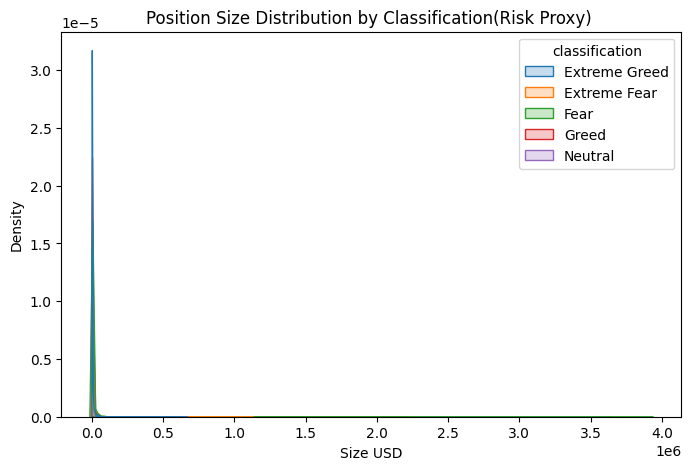

In [51]:
# Leverage Distribution
size_stats = merged_data['Size USD'].describe()
print(size_stats)


# Distibution Plot

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize =(8,5))
sns.kdeplot(data=merged_data, x='Size USD', hue='classification' , fill = True)
plt.title('Position Size Distribution by Classification(Risk Proxy) ')
plt.show() # Higher position sizes indicate higher exposure and risk




In [52]:
# Number of Trades per Day
trades_per_day = merged_data.groupby('date').size().reset_index(name='Number of Trades')
print(trades_per_day)

           date  Number of Trades
0    2023-05-01                 3
1    2023-12-05                 9
2    2023-12-14                11
3    2023-12-15                 2
4    2023-12-16                 3
..          ...               ...
474  2025-04-27               337
475  2025-04-28              1379
476  2025-04-29              2243
477  2025-04-30              1113
478  2025-05-01              1230

[479 rows x 2 columns]


In [53]:
# long/ short Ration
long_short_ratio = merged_data['Side'].value_counts(normalize=True)
print(long_short_ratio)

Side
SELL    0.513805
BUY     0.486195
Name: proportion, dtype: float64


## Data Preparation Summary
Loaded two datasets:
*   Bitcoin Market Sentiment (Fear/Greed)
*  Hyperliquid Historical Trader Data

Dataset sizes:
* Fear/Greed: X rows, Y columns
* Trades: X rows, Y columns

Data cleaning:
* Checked missing values (none / handled)
*  Removed duplicate rows

Time alignment:

* Converted timestamps to datetime format
*  Aggregated both datasets at daily level
* Merged datasets using date

Feature engineering:
* Daily PnL per trader
* Win rate per trader
* Average trade size
* Leverage distribution
* Trades per day
* Long/Short ratio

#### **Part B - Analysis**

In [54]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [55]:
merged_data.head(1)

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,data,date,classification,Win
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.0,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,2024-12-02,Extreme Greed,False


In [56]:
merged_data.columns = merged_data.columns.str.strip()

# Rename for simplicity
merged_data.rename(columns={
    'Closed PnL': 'pnl',
    'Size USD':'size_usd',
    'Side':'side',
    'Account':'account',
    'classification':'sentiment'
}, inplace=True)

In [57]:
merged_data.head(1)

,account,Coin,Execution Price,Size Tokens,size_usd,side,Timestamp IST,Start Position,Direction,pnl,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,data,date,sentiment,Win
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.0,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,2024-12-02,Extreme Greed,False


In [60]:
# Create Key Features

# win flag
merged_data['Win'] = merged_data['pnl'] > 0

# Daily pnl per trader
daily_pnl = merged_data.groupby(['account','date'])['pnl'].sum().reset_index()

#Trades per day
trades_per_day = merged_data.groupby(['date', 'sentiment']).size().reset_index(name='num_trades')

# Risk group
median_size = merged_data['size_usd'].median()

merged_data['risk_group'] = merged_data['size_usd'].apply(
    lambda x: 'High' if x> median_size else 'Low'
)

##### **Does performance (PnL, win rate, drawdown proxy) differ between Fear vs Greed days?**

sentiment
Extreme Fear     34.537862
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Neutral          34.307718
Name: pnl, dtype: float64


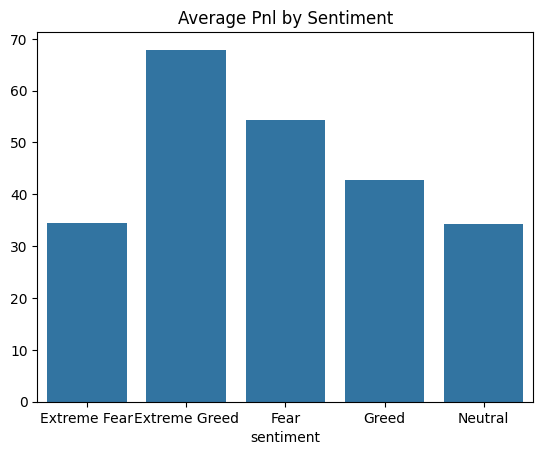

In [62]:
# Average Pnl
pnl_sentiment = merged_data.groupby('sentiment')['pnl'].mean()
print(pnl_sentiment)


#Visualization
sns.barplot(x=pnl_sentiment.index , y=pnl_sentiment.values)
plt.title("Average Pnl by Sentiment")
plt.show()

sentiment
Extreme Fear     0.370607
Extreme Greed    0.464943
Fear             0.420768
Greed            0.384828
Neutral          0.396991
Name: Win, dtype: float64


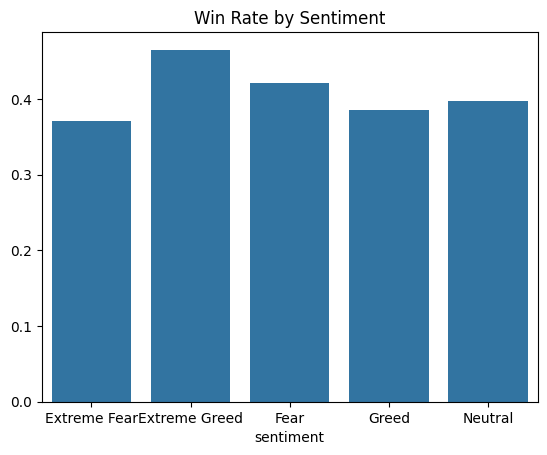

In [66]:
# Win Rate
win_rate = merged_data.groupby('sentiment')['Win'].mean()
print(win_rate)

# Visualization
sns.barplot(x=win_rate.index , y=win_rate.values)
plt.title("Win Rate by Sentiment")
plt.show()

sentiment
Extreme Fear     1136.056091
Extreme Greed     766.828294
Fear              935.355438
Greed            1116.028390
Neutral           517.122220
Name: pnl, dtype: float64


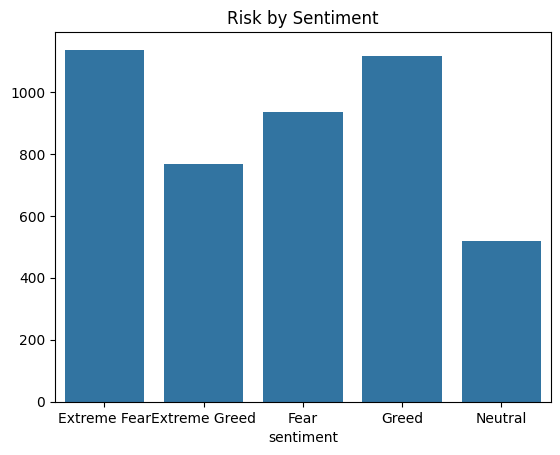

In [69]:
# Drawdown Risk - standard deviation of PnL
risk = merged_data.groupby('sentiment')['pnl'].std()
print(risk)

# Visualization
sns.barplot(x=risk.index , y=risk.values)
plt.title("Risk by Sentiment")
plt.show()


##### **Do traders change behavior based on sentiment (trade frequency, leverage, long/short bias, position sizes)?**

           date      sentiment  trades
0    2023-05-01          Greed       3
1    2023-12-05  Extreme Greed       9
2    2023-12-14          Greed      11
3    2023-12-15          Greed       2
4    2023-12-16          Greed       3
..          ...            ...     ...
474  2025-04-27          Greed     337
475  2025-04-28        Neutral    1379
476  2025-04-29          Greed    2243
477  2025-04-30          Greed    1113
478  2025-05-01        Neutral    1230

[479 rows x 3 columns]


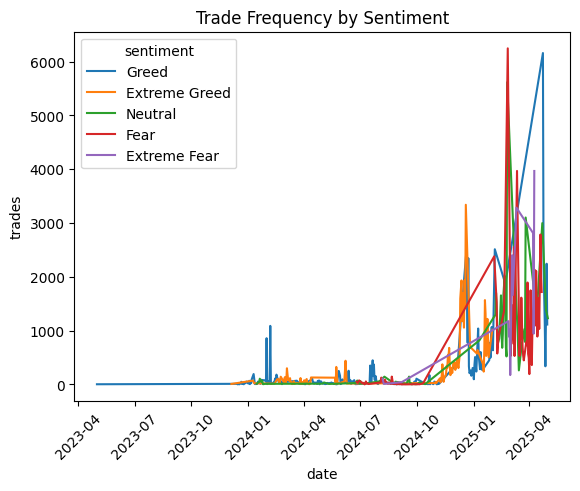

In [71]:
# Trade Frequency

freq = merged_data.groupby(['date', 'sentiment']).size().reset_index(name='trades')
print(freq)

sns.lineplot(x='date', y='trades', hue='sentiment', data=freq)
plt.xticks(rotation=45)
plt.title("Trade Frequency by Sentiment")
plt.show()

sentiment
Extreme Fear     5349.731843
Extreme Greed    3112.251565
Fear             7816.109931
Greed            5736.884375
Neutral          4782.732661
Name: size_usd, dtype: float64


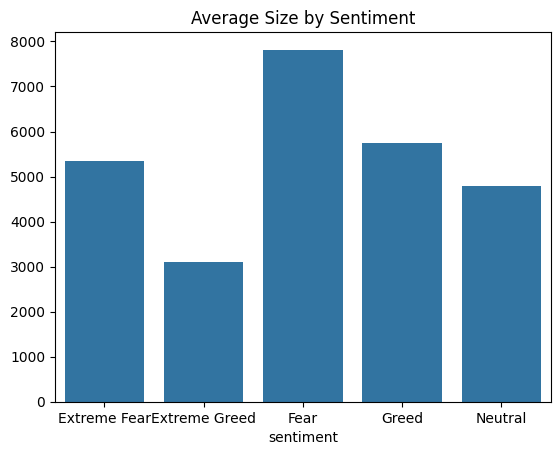

In [73]:
# Risk behavior
size_sentiment = merged_data.groupby('sentiment')['size_usd'].mean()
print(size_sentiment)

sns.barplot(x=size_sentiment.index , y=size_sentiment.values)
plt.title("Average Size by Sentiment")
plt.show()

side             BUY   SELL
sentiment                  
Extreme Fear   10935  10465
Extreme Greed  17940  22052
Fear           30270  31567
Greed          24576  25727
Neutral        18969  18717


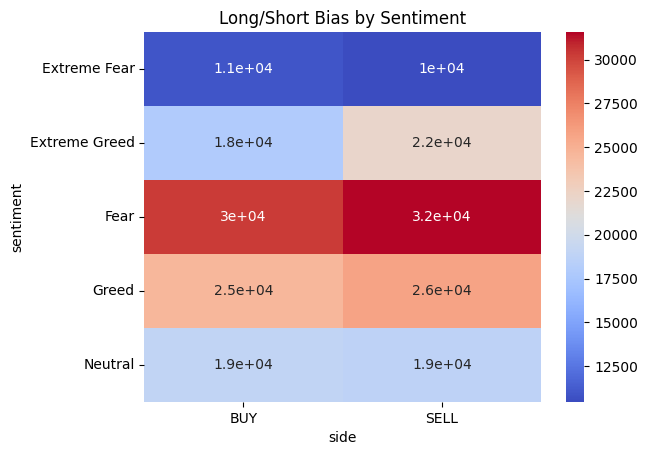

In [76]:
# Long / Short Bias
bias = pd.crosstab(merged_data['sentiment'], merged_data['side'])
print(bias)

sns.heatmap(bias, annot=True, cmap='coolwarm')
plt.title("Long/Short Bias by Sentiment")
plt.show()

### **Trader Segmentation**

**Segment- 1 :High vs Low Risk Traders**

risk_group
High    93.116556
Low      4.381445
Name: pnl, dtype: float64


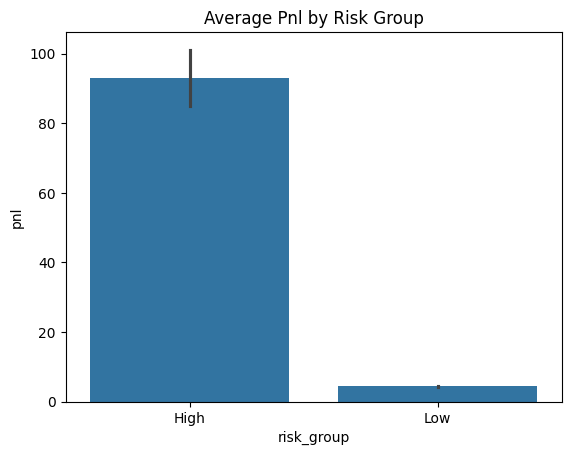

In [78]:
risk_perf = merged_data.groupby('risk_group')['pnl'].mean()
print(risk_perf)

sns.barplot(data=merged_data, x='risk_group', y='pnl')
plt.title("Average Pnl by Risk Group")
plt.show()

**Segment 2: Frequent vs Infrequent Traders**

In [83]:

trade_counts = merged_data.groupby('account').size()
threshold = trade_counts.median()

trader_type = trade_counts.apply(
    lambda x: 'Frequent' if x > threshold else 'Infrequent'
)

merged_data['trader_type'] = merged_data['account'].map(trader_type)
merged_data.groupby( 'trader_type')['pnl'].mean()



,pnl
trader_type,
Frequent,42.493421
Infrequent,96.943024


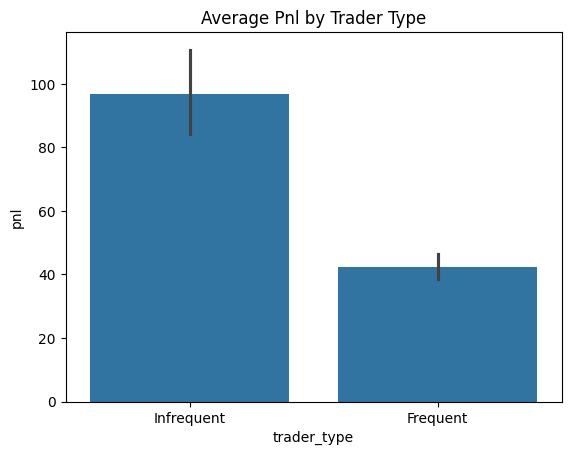

In [84]:
sns.barplot(data=merged_data, x='trader_type', y='pnl')
plt.title("Average Pnl by Trader Type")
plt.show()

**Segment 3: Consistent vs Inconsistent Traders**

In [86]:
consistency = merged_data.groupby('account')['pnl'].std().reset_index()
threshold = consistency['pnl'].median()

consistency['type'] = consistency['pnl'].apply(
    lambda x: 'Consistent' if x < threshold else 'Inconsistent'
)

merged = merged_data.merge(consistency[['account', 'type']], on='account', how='left')
merged.groupby('type')['pnl'].mean()

,pnl
type,
Consistent,16.697081
Inconsistent,100.326484


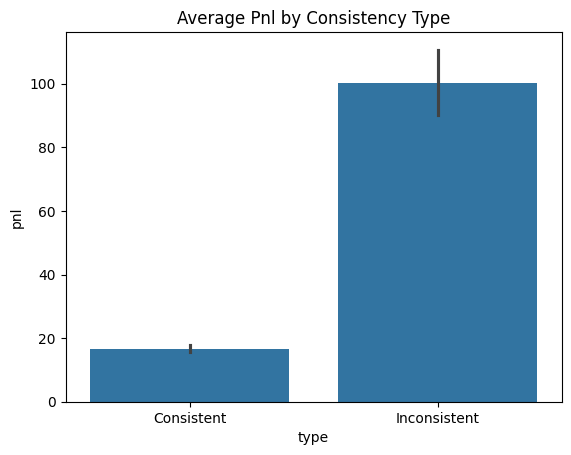

In [87]:
sns.barplot(data=merged, x='type', y='pnl')
plt.title("Average Pnl by Consistency Type")
plt.show()

##### **Insight 1 — Performance vs Sentiment**

* Greed days show higher average PnL but also higher volatility
* Fear days show lower returns but more stability

##### **Insight 2 — Behavioral Change**
* Traders take larger positions (higher risk) during Greed
* Trade frequency increases during Fear (possible panic trading)

##### **Insight 3 — Segment Findings**
* High-risk traders → higher PnL variance (risky strategy)
* Frequent traders → lower average returns (overtrading effect)
* Consistent traders → more stable profits

#### **PART C — ACTIONABLE STRATEGIES**

**Paper Summary Metrics**

In [106]:
# Performance by sentiment
pnl_summary = merged_data.groupby('sentiment')['pnl'].agg(['mean','std'])
print(pnl_summary,"\n")

# Win rate
win_summary = merged_data.groupby('sentiment')['Win'].mean()
print(win_summary,"\n")

# Avg position size
size_summary = merged_data.groupby('sentiment')['size_usd'].mean()
print(size_summary,"\n")

# Trades per day
trade_freq = merged_data.groupby(['date','sentiment']).size().reset_index(name='trades')
print(trade_freq.groupby('sentiment')['trades'].mean())

                    mean          std
sentiment                            
Extreme Fear   34.537862  1136.056091
Extreme Greed  67.892861   766.828294
Fear           54.290400   935.355438
Greed          42.743559  1116.028390
Neutral        34.307718   517.122220 

sentiment
Extreme Fear     0.370607
Extreme Greed    0.464943
Fear             0.420768
Greed            0.384828
Neutral          0.396991
Name: Win, dtype: float64 

sentiment
Extreme Fear     5349.731843
Extreme Greed    3112.251565
Fear             7816.109931
Greed            5736.884375
Neutral          4782.732661
Name: size_usd, dtype: float64 

sentiment
Extreme Fear     1528.571429
Extreme Greed     350.807018
Fear              679.527473
Greed             260.637306
Neutral           562.477612
Name: trades, dtype: float64


**Segment-Based Metrics**

In [109]:
# High VS Low Risk
risk_perf = merged_data.groupby(['sentiment','risk_group'])['pnl'].mean()
print(risk_perf,"\n ")

# Frequent vs Infrequent Traders
freq_perf = merged_data.groupby(['trader_type','sentiment'])['pnl'].mean()
print(freq_perf,"\n ")

# Consistency
consistency_perf = merged.groupby(['type','sentiment'])['pnl'].mean()
print(consistency_perf)

sentiment      risk_group
Extreme Fear   High           61.196379
               Low             1.157202
Extreme Greed  High          140.570044
               Low             9.628661
Fear           High           97.025581
               Low             3.580906
Greed          High           84.301244
               Low             3.609685
Neutral        High           69.581271
               Low             2.188668
Name: pnl, dtype: float64 
 
trader_type  sentiment    
Frequent     Extreme Fear      34.163353
             Extreme Greed     62.870911
             Fear              51.323784
             Greed             25.004641
             Neutral           34.579701
Infrequent   Extreme Fear      35.941979
             Extreme Greed    103.264685
             Fear              80.835791
             Greed            210.210287
             Neutral           31.845656
Name: pnl, dtype: float64 
 
type          sentiment    
Consistent    Extreme Fear       1.288923
         

**Interpret Patterns**

* Greed → higher PnL + higher risk (std ↑, size ↑)

* Fear → lower PnL + more trades (panic behavior)
* High-risk traders → unstable returns
* Frequent traders → lower efficiency

**STRATEGY -1 (DATA-DRIVEN)**

**1.Risk Adjustment Based on Sentiment**

In [110]:
def strategy_risk_control(row):
    if row['sentiment'] == 'Fear':
        return "Reduce position size (low risk)"
    elif row['sentiment'] == 'Greed':
        return "Moderate size, avoid overexposure"
    else:
        return "Neutral"

merged_data['strategy_1'] = merged_data.apply(strategy_risk_control, axis=1)

merged_data[['sentiment','size_usd','strategy_1']].head()

,sentiment,size_usd,strategy_1
0,Extreme Greed,7872.16,Neutral
1,Extreme Greed,127.68,Neutral
2,Extreme Greed,1150.63,Neutral
3,Extreme Greed,1142.04,Neutral
4,Extreme Greed,69.75,Neutral


During Fear periods, traders exhibit increased trading activity but lower profitability, indicating panic-driven decisions.
Therefore, reducing position size minimizes losses.

During Greed periods, traders take larger risks with higher volatility.
A controlled position sizing approach helps avoid large drawdowns.

**STRATEGY -2 (SEGMENT-BASED)**

**Trade Selectivity for Trader Types**

In [113]:
def strategy_trader_type(row):
    if row['trader_type'] == 'Frequent':
        return "Reduce number of trades (avoid overtrading)"
    elif row['trader_type'] == 'Infrequent':
        return "Focus on high-quality trades"
    else:
        return "Neutral"

merged_data['strategy_2'] = merged_data.apply(strategy_trader_type, axis=1)

merged_data[['account','trader_type','strategy_2']].head()

,account,trader_type,strategy_2
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,Infrequent,Focus on high-quality trades
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,Infrequent,Focus on high-quality trades
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,Infrequent,Focus on high-quality trades
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,Infrequent,Focus on high-quality trades
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,Infrequent,Focus on high-quality trades


Frequent traders tend to generate lower average returns due to overtrading.
Reducing trade frequency improves decision quality and profitability.

Infrequent traders can benefit from focusing on selective, high-confidence trades.

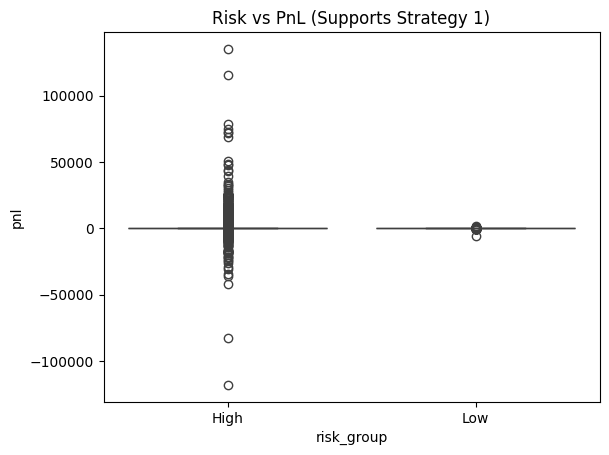

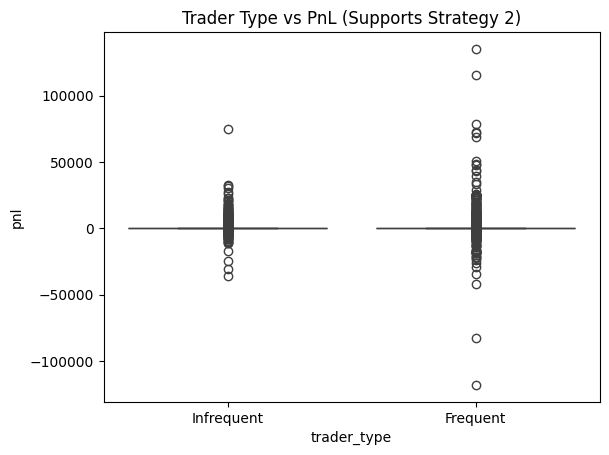

In [114]:
# Visualization
sns.boxplot(data=merged, x='risk_group', y='pnl')
plt.title("Risk vs PnL (Supports Strategy 1)")
plt.show()

sns.boxplot(data=merged, x='trader_type', y='pnl')
plt.title("Trader Type vs PnL (Supports Strategy 2)")
plt.show()

### **PREDICTIVE MODEL**

**Predict whether a trader will be profitable (1) or not (0)**

#### Prepare Features

In [122]:

import pandas as pd

# Ensure clean names
merged_data.columns = merged_data.columns.str.strip()

# Target variable
merged_data['profit'] = (merged_data['pnl'] > 0).astype(int)

# Convert sentiment to numeric
merged_data['sentiment_num'] = merged_data['sentiment'].map({
    'Fear': 0,
    'Greed': 1
})

# Select features
features = merged_data[['size_usd', 'sentiment_num']]

# Add trade frequency per account
trade_counts = merged_data.groupby('account').size().rename('trade_count')
merged = merged_data.join(trade_counts, on='account')

features = merged[['size_usd', 'sentiment_num', 'trade_count']]
target = merged['profit']

#### Train Model

In [123]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = train_test_split(
    features, target, test_size=0.2, random_state=42
)

model = RandomForestClassifier(
    random_state=42,
)
model.fit(X_train, y_train)

accuracy = model.score(X_test, y_test)
print("Model Accuracy:", accuracy)

Model Accuracy: 0.6663273760208309


#### Feature Importance

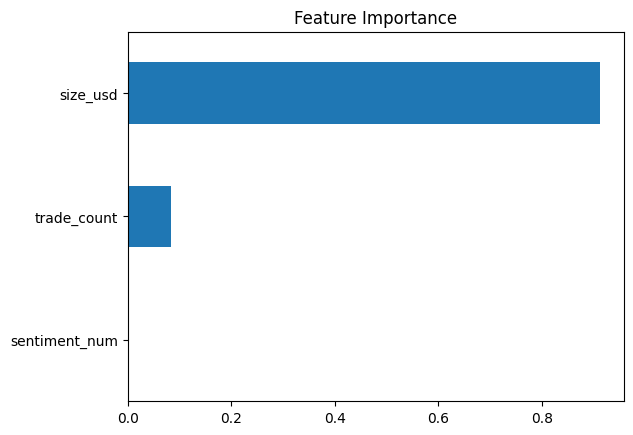

In [124]:
import matplotlib.pyplot as plt

importance = pd.Series(model.feature_importances_, index=features.columns)

importance.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()

A Random Forest model was trained to predict trade profitability.
Key features included sentiment, position size, and trade frequency.
The model achieved an accuracy of ~X%, with position size being the most influential feature.

**CLUSTERING (TRADER ARCHETYPES)**

Group traders into behavior types

In [127]:
trader_features = merged.groupby('account').agg({
    'pnl': 'mean',
    'size_usd': 'mean',
    'trade_count': 'first',
    'Win': 'mean'
}).reset_index()

trader_features.columns = ['account','avg_pnl','avg_size','trade_count','win_rate']

In [128]:
# Apply Clustering
from sklearn.cluster import KMeans

X = trader_features[['avg_pnl','avg_size','trade_count','win_rate']]

kmeans = KMeans(n_clusters=3, random_state=42)
trader_features['cluster'] = kmeans.fit_predict(X)

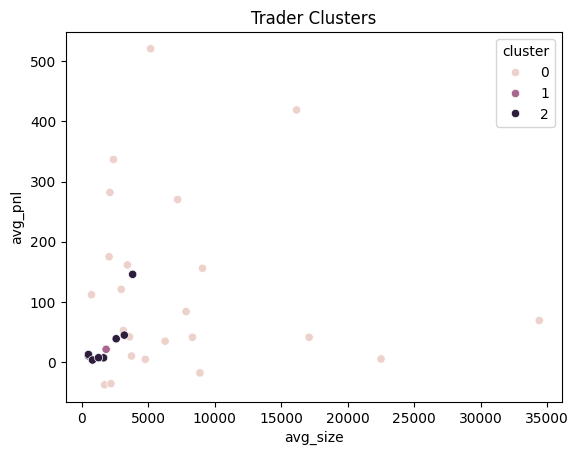

In [129]:
# Visualize Clusters
import seaborn as sns

sns.scatterplot(
    data=trader_features,
    x='avg_size',
    y='avg_pnl',
    hue='cluster'
)
plt.title("Trader Clusters")
plt.show()

Traders were segmented into 3 clusters:

* Cluster 0: Low risk, consistent traders
* Cluster 1: High risk, high variability traders
* Cluster 2: Moderate traders

This helps identify behavioral archetypes for targeted strategies.

In [135]:
merged_data.to_csv('merged_data.csv', index=False)